# 2. Análisis exploratorio de datos

Este capítulo analiza la población completa de préstamos con resultado final conocido. Los cálculos descriptivos y las pruebas estadísticas utilizan todas las observaciones elegibles; no se realiza muestreo. Se priorizan variables conocidas al momento de originar el préstamo, porque las variables de pagos posteriores producirían fuga de información.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

candidates = [
    Path('../accepted_2007_to_2018Q4.csv'),
    Path('../../accepted_2007_to_2018Q4.csv'),
    Path('Tarea1/accepted_2007_to_2018Q4.csv'),
]
CSV_PATH = next((p.resolve() for p in candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError('No se encontró accepted_2007_to_2018Q4.csv')

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGURES_DIR = PROJECT_DIR / 'figures' / 'eda'
RESULTS_DIR = PROJECT_DIR / 'results' / 'eda'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Fuente: {CSV_PATH}')

Fuente: C:\Users\Valentina Figueroa\OneDrive - Universidad del Norte\PERSONAL\MAESTRÍA ANALÍTICA DE DATOS\Machine Learning\Tarea1\accepted_2007_to_2018Q4.csv


## 2.1 Variables seleccionadas

Las variables principales provienen de la guía. Se agregan `grade`, `term`, `issue_d` y `verification_status` por su utilidad descriptiva. No se usan variables como `total_pymnt`, `recoveries`, `last_pymnt_d` o `out_prncp`, porque solo se conocen después de otorgar el préstamo y revelarían directamente su resultado.

In [2]:
numeric_cols = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_range_high',
]
categorical_cols = [
    'emp_length', 'purpose', 'home_ownership', 'addr_state',
    'verification_status', 'grade', 'term',
]
usecols = ['id', 'loan_status', 'issue_d'] + numeric_cols + categorical_cols
target_map = {'Fully Paid': 0, 'Charged Off': 1}

parts = []
for chunk in pd.read_csv(CSV_PATH, usecols=usecols, chunksize=150_000, low_memory=False):
    valid_id = chunk['id'].astype('string').str.fullmatch(r'\d+', na=False)
    eligible = valid_id & chunk['loan_status'].isin(target_map)
    if eligible.any():
        part = chunk.loc[eligible].copy()
        part['default'] = part['loan_status'].map(target_map).astype('int8')
        parts.append(part)

df = pd.concat(parts, ignore_index=True)
del parts
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

print(f'Filas elegibles: {len(df):,}')
print(f'Columnas analizadas: {df.shape[1]}')
display(df.head())
display(df.tail())
df.info(memory_usage='deep')

Filas elegibles: 1,345,310
Columnas analizadas: 16


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,fico_range_high,default
0,68407277,"3,600.0000",36 months,13.9900,C,10+ years,MORTGAGE,"55,000.0000",Not Verified,2015-12-01,Fully Paid,debt_consolidation,PA,5.9100,679.0000,0
1,68355089,"24,700.0000",36 months,11.9900,C,10+ years,MORTGAGE,"65,000.0000",Not Verified,2015-12-01,Fully Paid,small_business,SD,16.0600,719.0000,0
2,68341763,"20,000.0000",60 months,10.7800,B,10+ years,MORTGAGE,"63,000.0000",Not Verified,2015-12-01,Fully Paid,home_improvement,IL,10.7800,699.0000,0
3,68476807,"10,400.0000",60 months,22.4500,F,3 years,MORTGAGE,"104,433.0000",Source Verified,2015-12-01,Fully Paid,major_purchase,PA,25.3700,699.0000,0
4,68426831,"11,950.0000",36 months,13.4400,C,4 years,RENT,"34,000.0000",Source Verified,2015-12-01,Fully Paid,debt_consolidation,GA,10.2000,694.0000,0


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,fico_range_high,default
1345305,89905081,"18,000.0000",60 months,9.4900,B,5 years,OWN,"130,000.0000",Not Verified,2016-10-01,Fully Paid,home_improvement,TX,20.5900,739.0000,0
1345306,88948836,"29,400.0000",60 months,13.9900,C,9 years,MORTGAGE,"180,792.0000",Not Verified,2016-10-01,Fully Paid,debt_consolidation,CA,22.0300,709.0000,0
1345307,89996426,"32,000.0000",60 months,14.4900,C,3 years,MORTGAGE,"157,000.0000",Source Verified,2016-10-01,Charged Off,home_improvement,AZ,10.3400,739.0000,1
1345308,90006534,"16,000.0000",60 months,12.7900,C,10+ years,RENT,"150,000.0000",Not Verified,2016-10-01,Fully Paid,medical,NC,12.2500,669.0000,0
1345309,88224441,"24,000.0000",60 months,14.4900,C,6 years,RENT,"110,000.0000",Not Verified,2016-10-01,Charged Off,debt_consolidation,FL,18.3000,664.0000,1


<class 'pandas.DataFrame'>
RangeIndex: 1345310 entries, 0 to 1345309
Data columns (total 16 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   id                   1345310 non-null  object        
 1   loan_amnt            1345310 non-null  float64       
 2   term                 1345310 non-null  str           
 3   int_rate             1345310 non-null  float64       
 4   grade                1345310 non-null  str           
 5   emp_length           1266799 non-null  str           
 6   home_ownership       1345310 non-null  str           
 7   annual_inc           1345310 non-null  float64       
 8   verification_status  1345310 non-null  str           
 9   issue_d              1345310 non-null  datetime64[us]
 10  loan_status          1345310 non-null  str           
 11  purpose              1345310 non-null  str           
 12  addr_state           1345310 non-null  str           
 13  dti     

La selección reduce las 151 columnas originales a 16 campos para describir la población: las variables predictoras, el estado del préstamo, la fecha de originación, el identificador y el target derivado. El número de filas sigue siendo 1.345.310; aquí se reducen columnas irrelevantes para este análisis, no se toma una muestra de préstamos.

## 2.2 Calidad, tipos y valores faltantes

Se revisan tipos, cobertura, número de categorías y valores faltantes antes de definir el preprocesamiento. La tabla se calcula sobre todas las observaciones elegibles; por tanto, sirve para identificar problemas de calidad sin usar todavía información de la partición de prueba para ajustar parámetros.

,tipo,n_no_nulos,n_nulos,pct_nulos,n_unicos
emp_length,str,1266799,78511,5.8359,11
dti,float64,1344936,374,0.0278,7067
term,str,1345310,0,0.0000,2
id,object,1345310,0,0.0000,1345310
int_rate,float64,1345310,0,0.0000,654
grade,str,1345310,0,0.0000,7
home_ownership,str,1345310,0,0.0000,6
loan_amnt,float64,1345310,0,0.0000,1556
annual_inc,float64,1345310,0,0.0000,64362
verification_status,str,1345310,0,0.0000,3


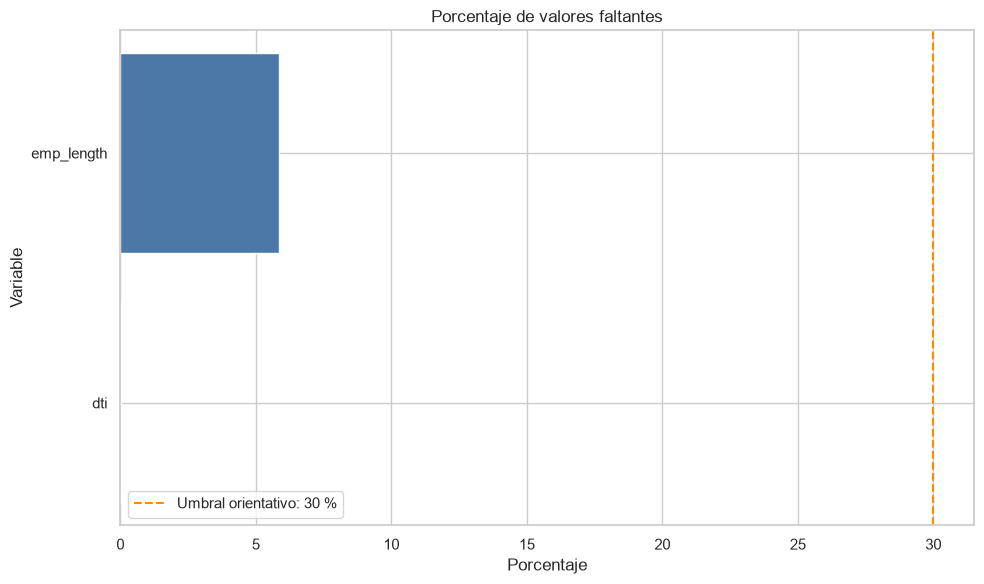

In [3]:
quality = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'n_no_nulos': df.notna().sum(),
    'n_nulos': df.isna().sum(),
    'pct_nulos': 100 * df.isna().mean(),
    'n_unicos': df.nunique(dropna=True),
}).sort_values('pct_nulos', ascending=False)
display(quality)
quality.to_csv(RESULTS_DIR / 'calidad_variables.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(10, 6))
missing_plot = quality.loc[quality['pct_nulos'] > 0].sort_values('pct_nulos')
ax.barh(missing_plot.index, missing_plot['pct_nulos'], color='#4C78A8')
ax.set(title='Porcentaje de valores faltantes', xlabel='Porcentaje', ylabel='Variable')
ax.axvline(30, color='darkorange', linestyle='--', label='Umbral orientativo: 30 %')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'valores_faltantes.png', dpi=150, bbox_inches='tight')
plt.show()

La tabla muestra que `emp_length` concentra 78.511 faltantes (5,84 %) y `dti` solo 374 (0,03 %); las demás variables analizadas están completas. Por su baja proporción, no se eliminan esas filas: el preprocesamiento posterior reemplaza faltantes numéricos por la mediana y conserva una categoría explícita para el empleo faltante. La línea del 30 % es una referencia para detectar problemas severos, no un umbral automático para borrar variables.

## 2.3 Distribución de la variable objetivo

La distribución de `default` determina el grado de desbalance y orienta la selección de métricas. Se reportan ambas clases antes de entrenar para evitar interpretar una accuracy alta como evidencia suficiente de capacidad predictiva.

,n,porcentaje
Fully Paid (0),1076751,80.0374
Charged Off (1),268559,19.9626


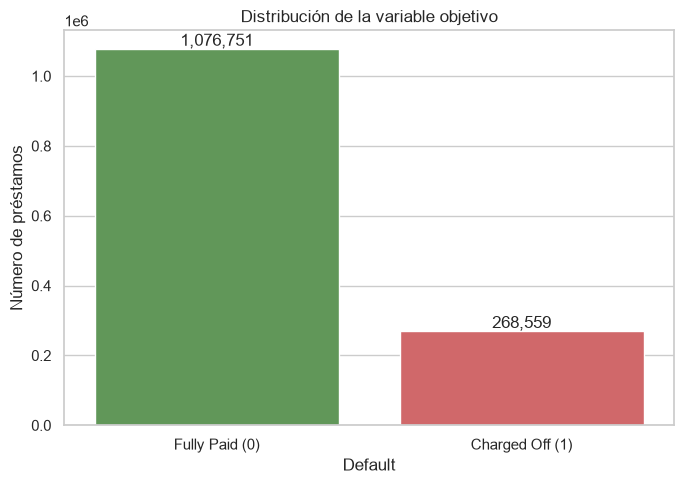

In [4]:
target_distribution = (
    df['default'].value_counts().sort_index().rename('n').to_frame()
    .assign(porcentaje=lambda x: 100 * x['n'] / x['n'].sum())
)
target_distribution.index = ['Fully Paid (0)', 'Charged Off (1)']
display(target_distribution)
target_distribution.to_csv(RESULTS_DIR / 'distribucion_target.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='default', hue='default', palette=['#59A14F', '#E15759'], legend=False, ax=ax)
ax.set(title='Distribución de la variable objetivo', xlabel='Default', ylabel='Número de préstamos')
ax.set_xticks([0, 1], ['Fully Paid (0)', 'Charged Off (1)'])
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

La clase `Charged Off` representa 19,96 % de la población. Un clasificador que siempre predijera `Fully Paid` obtendría aproximadamente 80 % de accuracy y no detectaría ningún default; por eso esa métrica aislada sería engañosa. La partición se estratifica para conservar esta proporción y también se reportan recall, F1, AUC ROC y AUC-PR.

## 2.4 Análisis unidimensional de variables numéricas

In [5]:
desc = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['mediana'] = df[numeric_cols].median()
desc['IQR'] = desc['75%'] - desc['25%']
desc['limite_inferior_IQR'] = desc['25%'] - 1.5 * desc['IQR']
desc['limite_superior_IQR'] = desc['75%'] + 1.5 * desc['IQR']
desc['n_outliers_IQR'] = {
    col: int(((df[col] < desc.loc[col, 'limite_inferior_IQR']) |
              (df[col] > desc.loc[col, 'limite_superior_IQR'])).sum())
    for col in numeric_cols
}
desc['pct_outliers_IQR'] = 100 * desc['n_outliers_IQR'] / desc['count']
desc['asimetria'] = df[numeric_cols].skew()
display(desc)
desc.to_csv(RESULTS_DIR / 'resumen_numericas.csv', encoding='utf-8-sig')

,count,mean,std,min,25%,50%,75%,max,mediana,IQR,limite_inferior_IQR,limite_superior_IQR,n_outliers_IQR,pct_outliers_IQR,asimetria
loan_amnt,"1,345,310.0000","14,419.9720","8,717.0508",500.0000,"8,000.0000","12,000.0000","20,000.0000","40,000.0000","12,000.0000","12,000.0000","-10,000.0000","38,000.0000",7157,0.5320,0.7825
int_rate,"1,345,310.0000",13.2396,4.7687,5.3100,9.7500,12.7400,15.9900,30.9900,12.7400,6.2400,0.3900,25.3500,24977,1.8566,0.7135
annual_inc,"1,345,310.0000","76,247.6364","69,925.0984",0.0000,"45,780.0000","65,000.0000","90,000.0000","10,999,200.0000","65,000.0000","44,220.0000","-20,550.0000","156,330.0000",65870,4.8963,46.3179
dti,"1,344,936.0000",18.2827,11.1604,-1.0000,11.7900,17.6100,24.0600,999.0000,17.6100,12.2700,-6.6150,42.4650,5473,0.4069,27.1106
fico_range_high,"1,345,310.0000",700.1852,31.8532,629.0000,674.0000,694.0000,714.0000,850.0000,694.0000,40.0000,614.0000,774.0000,46497,3.4562,1.2857


La mediana del monto solicitado es 12.000 y la del interés es 12,74 %. El ingreso anual tiene una mediana de 65.000 y una media de 76.248, señal de que algunos ingresos altos estiran la distribución hacia la derecha; el máximo supera 10 millones. `dti` tiene mediana 17,61, pero también un máximo de 999 que debe tratarse como valor extremo o código especial y no como un registro típico. La regla de 1,5 rangos intercuartílicos identifica observaciones alejadas de la parte central; no demuestra que sean errores ni justifica eliminarlas por sí sola.

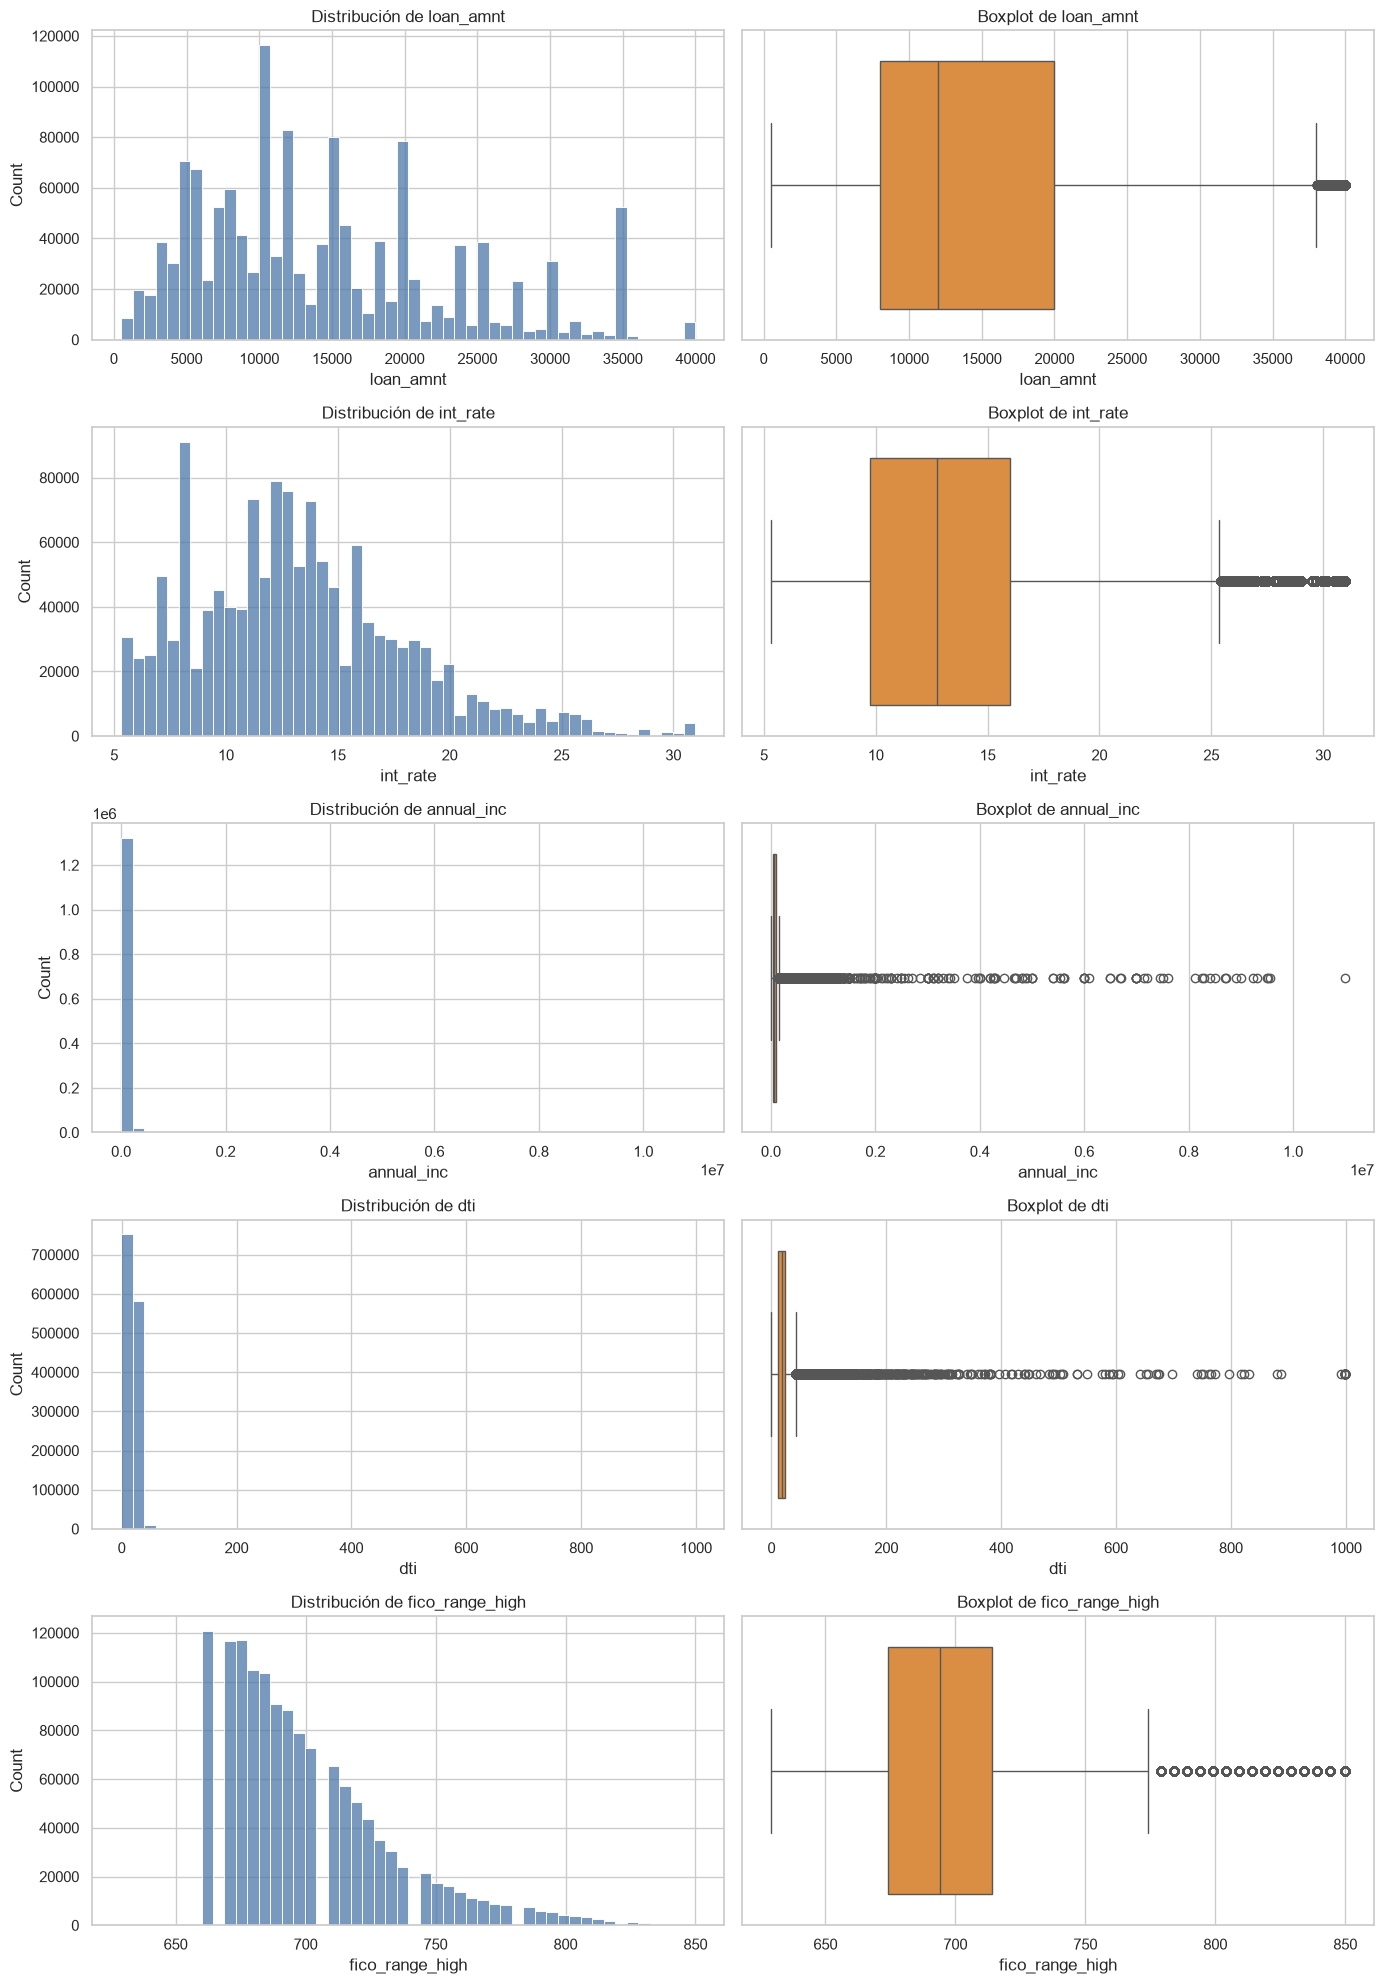

In [6]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    values = df[col].dropna()
    sns.histplot(values, bins=50, ax=axes[i, 0], color='#4C78A8')
    axes[i, 0].set_title(f'Distribución de {col}')
    sns.boxplot(x=values, ax=axes[i, 1], color='#F28E2B', showfliers=True)
    axes[i, 1].set_title(f'Boxplot de {col}')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'distribuciones_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

Los histogramas y diagramas de caja confirman que `annual_inc` tiene una cola derecha larga y que varias variables contienen valores extremos. Los puntos alejados se muestran aquí para inspección; no se quitan de la base. En la comparación principal se conserva la transformación común de imputación por mediana y estandarización, sin aplicar `log1p`, para no mezclar el efecto de una transformación adicional con la comparación entre modelos.

## 2.5 Análisis unidimensional de variables categóricas

Para cada variable se cuentan categorías y se marca la proporción de niveles raros. Esta revisión permite decidir si una categoría explícita para faltantes y `handle_unknown='ignore'` son suficientes para el preprocesamiento.

In [7]:
categorical_tables = {}
for col in categorical_cols:
    table = df[col].fillna('<MISSING>').value_counts(dropna=False).rename('n').to_frame()
    table['porcentaje'] = 100 * table['n'] / table['n'].sum()
    table['categoria_rara_menor_1pct'] = table['porcentaje'] < 1
    categorical_tables[col] = table
    print(f'\n{col}: {len(table)} categorías')
    display(table.head(20))
    table.to_csv(RESULTS_DIR / f'frecuencias_{col}.csv', encoding='utf-8-sig')


emp_length: 12 categorías


,n,porcentaje,categoria_rara_menor_1pct
emp_length,,,
10+ years,442199,32.8697,False
2 years,121743,9.0494,False
< 1 year,108061,8.0324,False
3 years,107597,7.9979,False
1 year,88494,6.5780,False
5 years,84154,6.2554,False
4 years,80556,5.9879,False
<MISSING>,78511,5.8359,False
6 years,62733,4.6631,False



purpose: 14 categorías


,n,porcentaje,categoria_rara_menor_1pct
purpose,,,
debt_consolidation,780321,58.0031,False
credit_card,295279,21.9488,False
home_improvement,87504,6.5044,False
other,77875,5.7886,False
major_purchase,29425,2.1872,False
medical,15554,1.1562,False
small_business,15416,1.1459,False
car,14585,1.0841,False
moving,9480,0.7047,True



home_ownership: 6 categorías


...

,n,porcentaje,categoria_rara_menor_1pct
verification_status,,,
Source Verified,521273,38.7474,False
Verified,418336,31.0959,False
Not Verified,405701,30.1567,False



grade: 7 categorías


,n,porcentaje,categoria_rara_menor_1pct
grade,,,
B,392741,29.1933,False
C,381686,28.3716,False
A,235090,17.4748,False
D,200953,14.9373,False
E,93650,6.9612,False
F,32058,2.3829,False
G,9132,0.6788,True



term: 2 categorías


,n,porcentaje,categoria_rara_menor_1pct
term,,,
36 months,1020743,75.8742,False
60 months,324567,24.1258,False


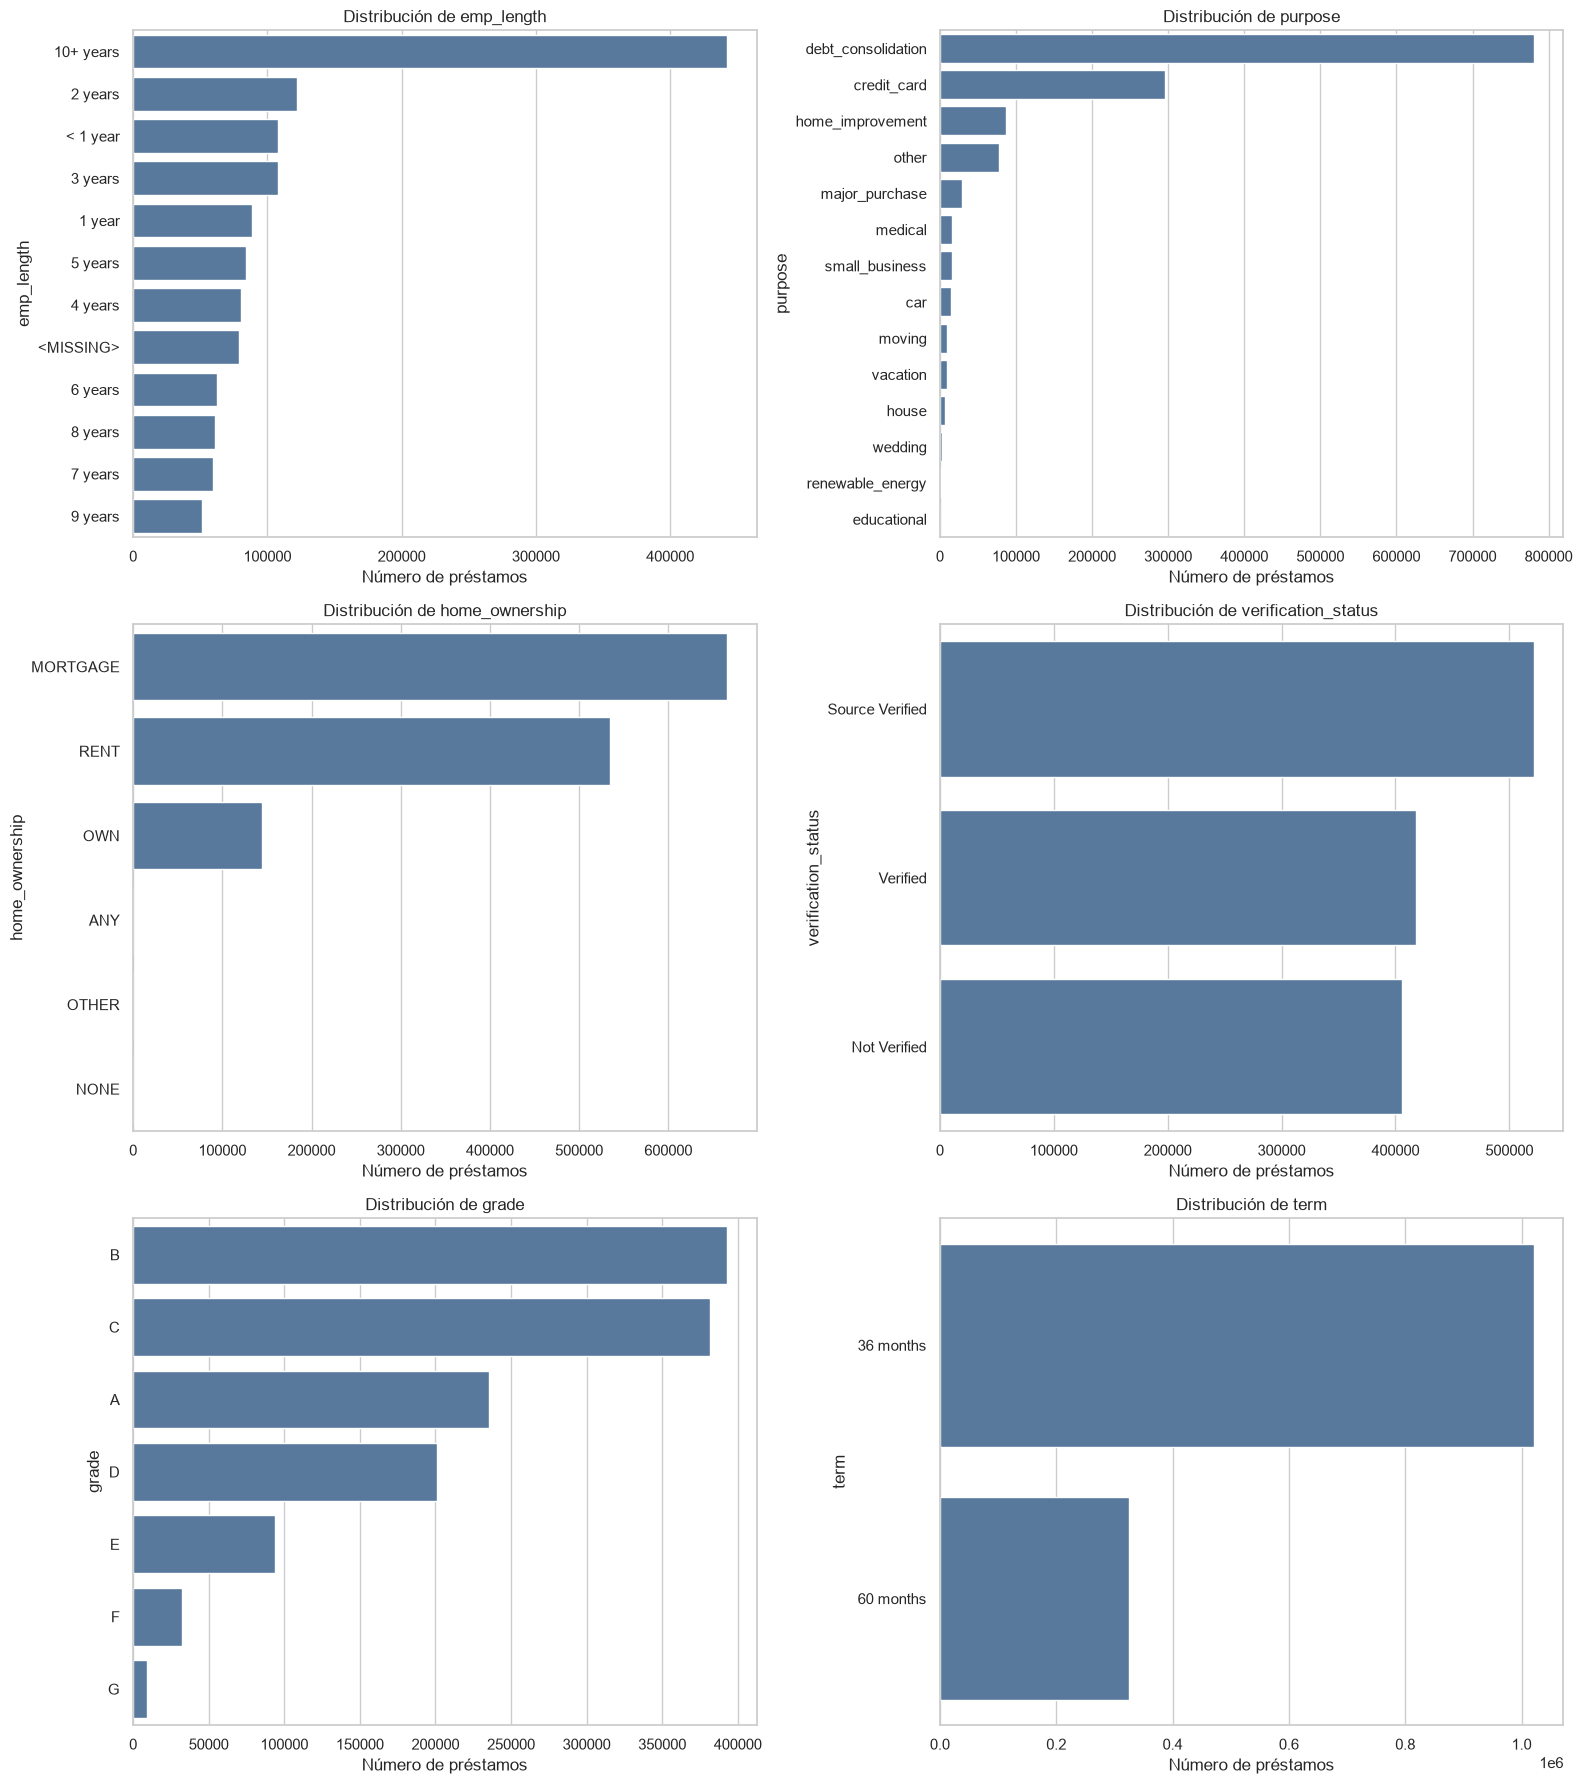

In [8]:
plot_cols = ['emp_length', 'purpose', 'home_ownership', 'verification_status', 'grade', 'term']
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for ax, col in zip(axes.flat, plot_cols):
    order = df[col].fillna('<MISSING>').value_counts().index
    sns.countplot(data=df.assign(**{col: df[col].fillna('<MISSING>')}), y=col, order=order, ax=ax, color='#4C78A8')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel('Número de préstamos')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'distribuciones_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

La cartera se concentra en consolidación de deuda (58,0 %) y tarjetas de crédito (21,9 %). El gráfico ordena las categorías por volumen, no por riesgo: una categoría frecuente no implica una mayor tasa de default. Los niveles con menos de 1 % se conservan en esta etapa; el codificador posterior puede representarlos individualmente y la interpretación de sus coeficientes debe tener en cuenta su menor soporte.

## 2.6 Variables numéricas frente a default

Se comparan las distribuciones de cada variable entre préstamos pagados y castigados. La prueba de Mann–Whitney se utiliza por la asimetría observada, mientras que la correlación punto-biserial resume la dirección y magnitud de la relación con la clase.

In [9]:
numeric_tests = []
for col in numeric_cols:
    clean = df[[col, 'default']].dropna()
    paid = clean.loc[clean['default'] == 0, col]
    defaulted = clean.loc[clean['default'] == 1, col]
    # Con este tamaño, se usa Mann-Whitney por robustez ante asimetría y outliers.
    statistic, p_value = stats.mannwhitneyu(paid, defaulted, alternative='two-sided')
    r_pb, p_pb = stats.pointbiserialr(clean['default'], clean[col])
    numeric_tests.append({
        'variable': col,
        'media_paid': paid.mean(),
        'media_default': defaulted.mean(),
        'diferencia_medias': defaulted.mean() - paid.mean(),
        'mediana_paid': paid.median(),
        'mediana_default': defaulted.median(),
        'mannwhitney_U': statistic,
        'p_mannwhitney': p_value,
        'correlacion_punto_biserial': r_pb,
        'p_punto_biserial': p_pb,
    })
numeric_tests = pd.DataFrame(numeric_tests).set_index('variable')
display(numeric_tests)
numeric_tests.to_csv(RESULTS_DIR / 'pruebas_numericas_vs_default.csv', encoding='utf-8-sig')

,media_paid,media_default,diferencia_medias,mediana_paid,mediana_default,mannwhitney_U,p_mannwhitney,correlacion_punto_biserial,p_punto_biserial
variable,,,,,,,,,
loan_amnt,"14,134.3698","15,565.0554","1,430.6856","12,000.0000","14,350.0000","129,804,235,071.0000",0.0000,0.0656,0.0000
int_rate,12.6233,15.7107,3.0874,12.2300,15.0500,"91,524,486,950.0000",0.0000,0.2588,0.0000
annual_inc,"77,705.9455","70,400.7433","-7,305.2022","65,000.0000","60,000.0000","158,568,849,776.5000",0.0000,-0.0418,0.0000
dti,17.8116,20.1712,2.3596,17.1100,19.7600,"122,222,806,999.5000",0.0000,0.0845,0.0000
fico_range_high,702.2641,691.8502,-10.4139,694.0000,684.0000,"171,590,901,833.5000",0.0000,-0.1307,0.0000


En promedio, los préstamos castigados presentan mayor tasa de interés (15,71 % frente a 12,62 %), mayor DTI (20,17 frente a 17,81) y un FICO menor (691,9 frente a 702,3). El ingreso mediano es 60.000 frente a 65.000 y el monto mediano es 14.350 frente a 12.000. Las pruebas de Mann–Whitney detectan diferencias en la distribución, pero los p-valores impresos como 0,0000 significan que son menores que la precisión mostrada, no que la probabilidad sea exactamente cero. La correlación punto-biserial ayuda a dimensionar la asociación: es mayor para interés (r≈0,259), mientras que monto, ingreso y DTI tienen asociaciones más débiles. Son relaciones descriptivas, no efectos causales.

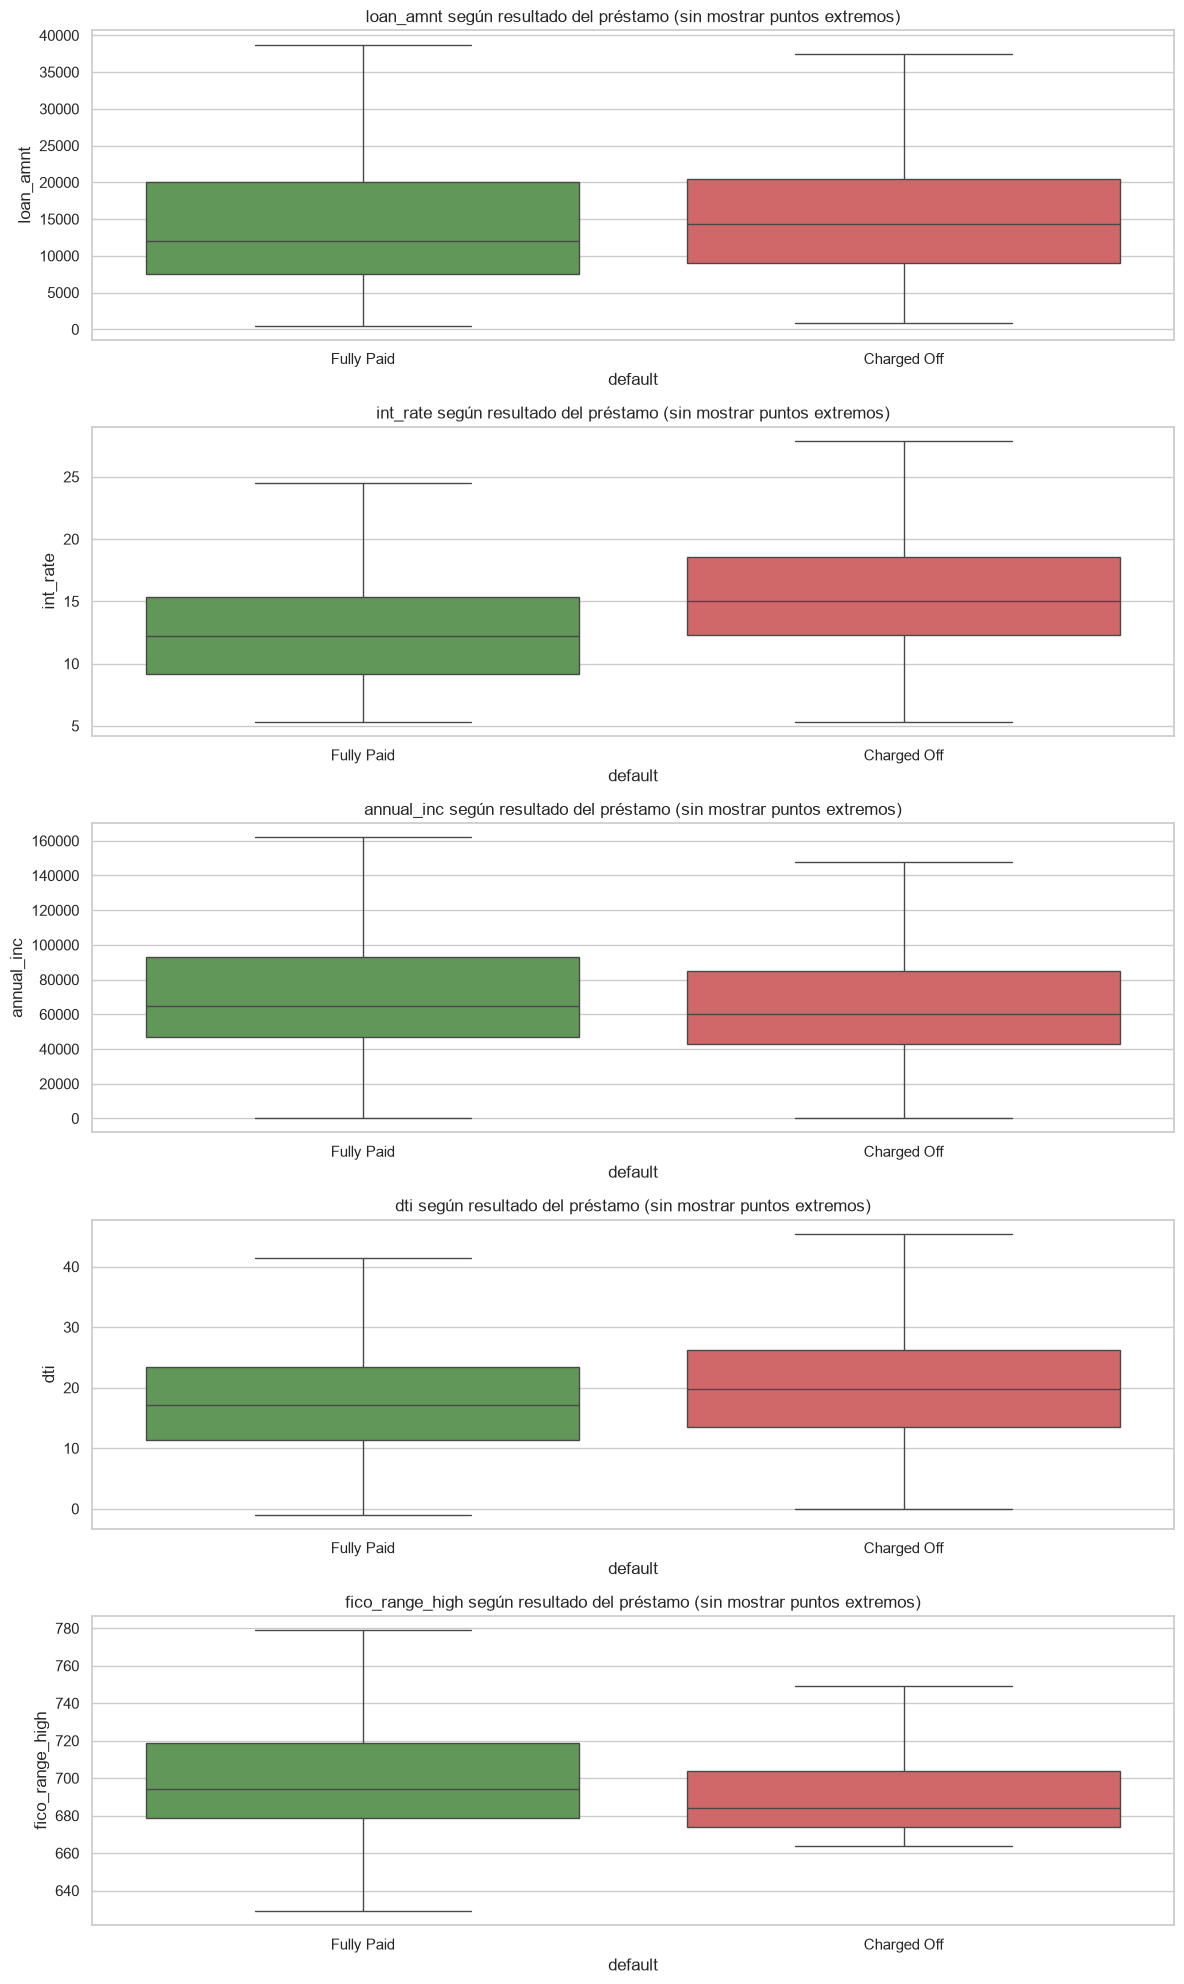

In [10]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4 * len(numeric_cols)))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='default', y=col, hue='default', palette=['#59A14F', '#E15759'], legend=False, ax=ax, showfliers=False)
    ax.set_title(f'{col} según resultado del préstamo (sin mostrar puntos extremos)')
    ax.set_xticks([0, 1], ['Fully Paid', 'Charged Off'])
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'boxplots_numericas_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

Los diagramas comparan medianas y dispersión entre `Fully Paid` y `Charged Off`. Para hacer visible la parte central se ocultan los puntos extremos en estas figuras; esos registros continúan en los cálculos y en la base. La dirección de las diferencias visuales coincide con la tabla, aunque las distribuciones se traslapan: ninguna de estas variables separa por sí sola todos los préstamos pagados de los castigados.

## 2.7 Variables categóricas frente a default

La prueba chi-cuadrado evalúa asociación global y V de Cramer aporta una medida de tamaño del efecto. Las tasas por categoría se muestran como apoyo descriptivo; no se convierten directamente en reglas de clasificación.

In [11]:
categorical_tests = []
default_rate_tables = {}
for col in categorical_cols:
    series = df[col].fillna('<MISSING>')
    contingency = pd.crosstab(series, df['default'])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt((chi2 / n) / min_dim) if min_dim > 0 else np.nan
    categorical_tests.append({
        'variable': col,
        'chi2': chi2,
        'grados_libertad': dof,
        'p_value': p_value,
        'V_Cramer': cramers_v,
    })
    rates = df.assign(_category=series).groupby('_category')['default'].agg(['count', 'mean'])
    rates['tasa_default_pct'] = 100 * rates['mean']
    rates = rates.sort_values('tasa_default_pct', ascending=False)
    default_rate_tables[col] = rates
    rates.to_csv(RESULTS_DIR / f'tasa_default_{col}.csv', encoding='utf-8-sig')

categorical_tests = pd.DataFrame(categorical_tests).set_index('variable')
display(categorical_tests)
categorical_tests.to_csv(RESULTS_DIR / 'chi2_categoricas_vs_default.csv', encoding='utf-8-sig')
display(default_rate_tables['grade'])

,chi2,grados_libertad,p_value,V_Cramer
variable,,,,
emp_length,"2,835.4109",11,0.0000,0.0459
purpose,"4,144.1960",13,0.0000,0.0555
home_ownership,"6,743.1900",5,0.0000,0.0708
addr_state,"3,403.5833",50,0.0000,0.0503
verification_status,"11,387.4390",2,0.0000,0.0920
grade,"92,284.2511",6,0.0000,0.2619
term,"41,716.8301",1,0.0000,0.1761


,count,mean,tasa_default_pct
_category,,,
G,9132,0.4993,49.9343
F,32058,0.4520,45.2024
E,93650,0.3848,38.4784
D,200953,0.3038,30.3822
C,381686,0.2244,22.4396
B,392741,0.1339,13.3852
A,235090,0.0604,6.0407


Todas las variables categóricas muestran asociación estadística con `default` en esta población, pero la magnitud importa: V de Cramer es 0,046–0,092 para la mayoría, y aumenta a 0,176 para plazo y 0,262 para `grade`. La tasa por `grade` sube de 6,0 % en A a 49,9 % en G; por plazo, es 16,0 % a 36 meses y 32,4 % a 60 meses. Las diferencias hacen que estos campos sean informativos para el modelo, pero no significan que plazo o calificación causen el impago. Los p-valores presentados como 0,0000 están por debajo del redondeo de la tabla.

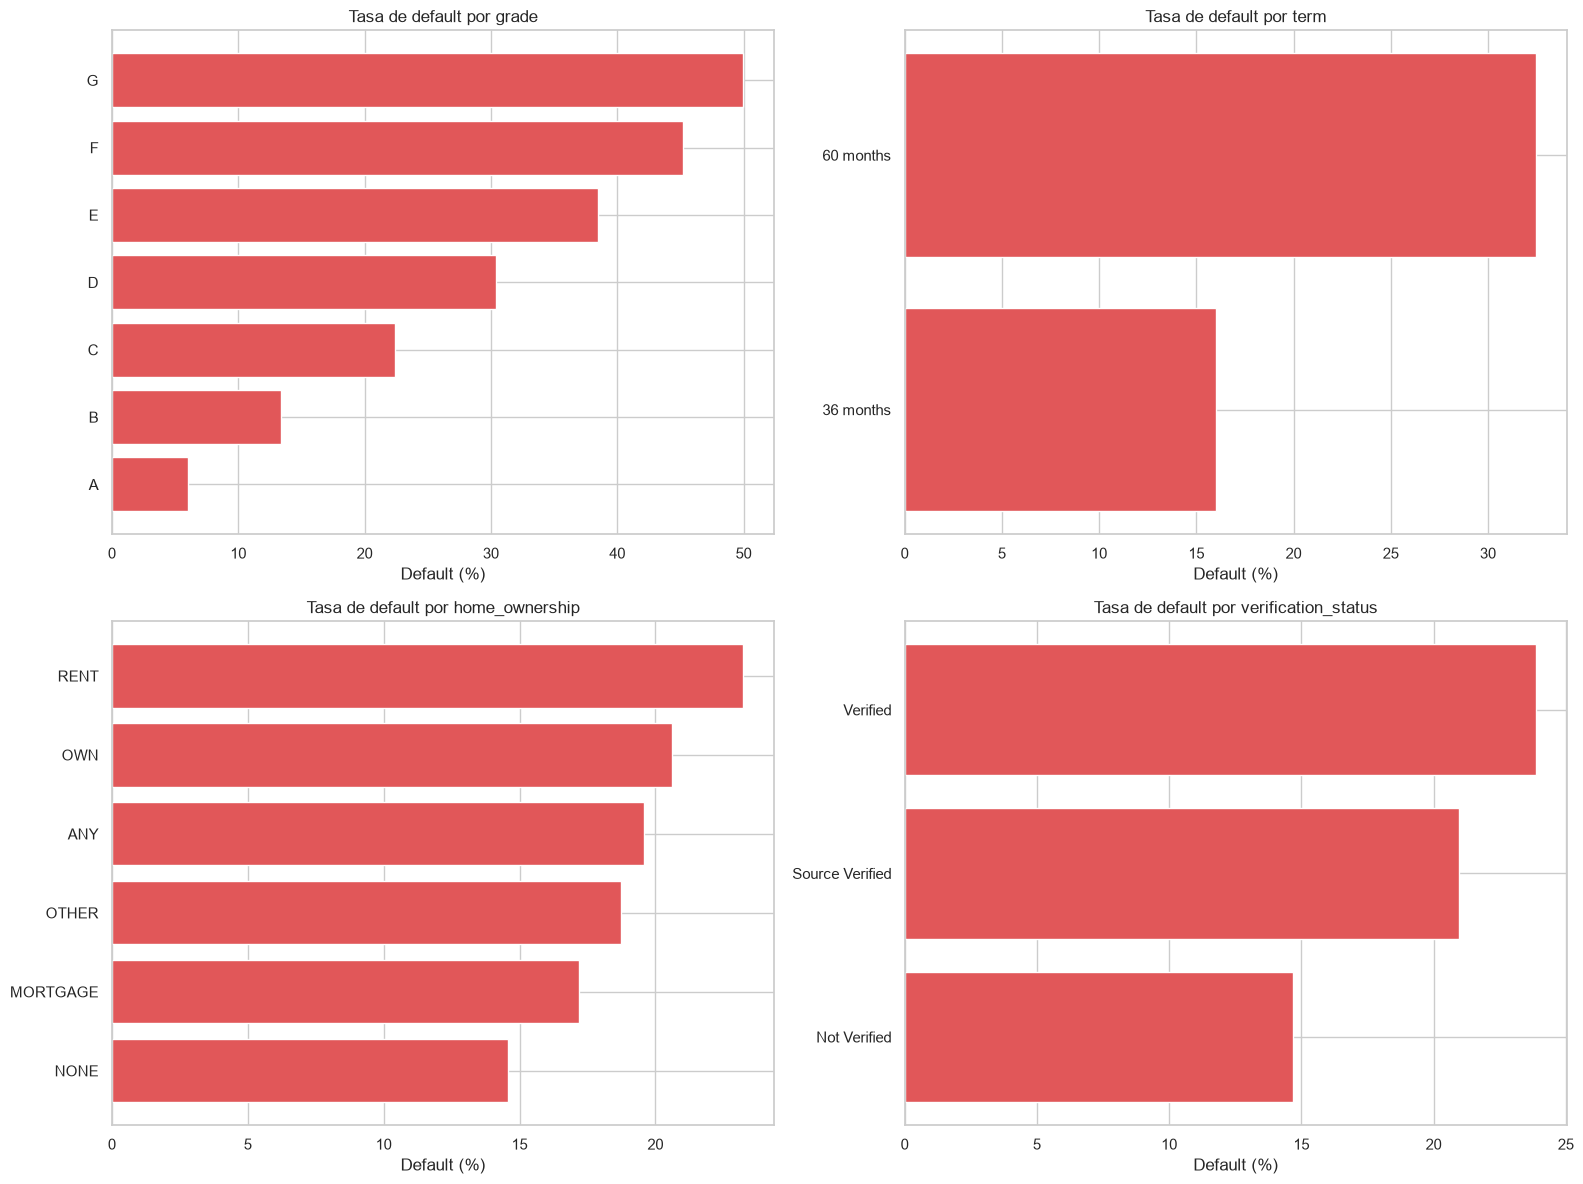

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, col in zip(axes.flat, ['grade', 'term', 'home_ownership', 'verification_status']):
    rates = default_rate_tables[col].sort_values('tasa_default_pct')
    ax.barh(rates.index.astype(str), rates['tasa_default_pct'], color='#E15759')
    ax.set_title(f'Tasa de default por {col}')
    ax.set_xlabel('Default (%)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tasas_default_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.8 Correlación y posibles redundancias

La matriz de Pearson se usa para detectar redundancia lineal entre numéricas y una posible relación excesiva con el target. El umbral `|r| > 0.7` se toma como señal exploratoria, no como criterio único para eliminar variables.

,loan_amnt,int_rate,annual_inc,dti,fico_range_high,default
loan_amnt,1.0000,0.1417,0.3118,0.0321,0.1010,0.0656
int_rate,0.1417,1.0000,-0.0722,0.1469,-0.4054,0.2588
annual_inc,0.3118,-0.0722,1.0000,-0.1405,0.0710,-0.0418
dti,0.0321,0.1469,-0.1405,1.0000,-0.0619,0.0845
fico_range_high,0.1010,-0.4054,0.0710,-0.0619,1.0000,-0.1307
default,0.0656,0.2588,-0.0418,0.0845,-0.1307,1.0000


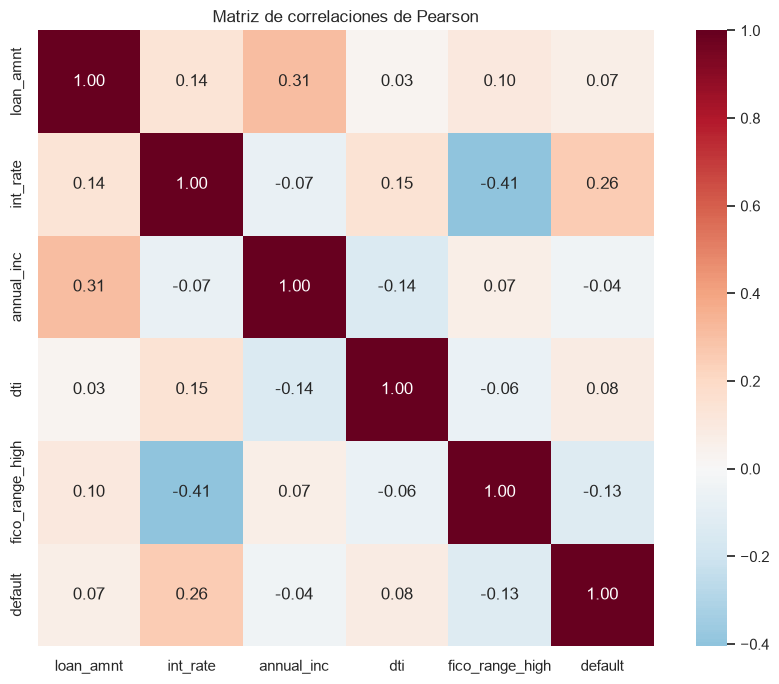

,resultado
0,No se encontraron pares con |r| > 0.7.


In [13]:
corr = df[numeric_cols + ['default']].corr(method='pearson')
display(corr)
corr.to_csv(RESULTS_DIR / 'correlaciones_pearson.csv', encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Matriz de correlaciones de Pearson')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'correlaciones_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack().rename('r').reset_index()
        .query('abs(r) > 0.7')
)
display(high_corr if not high_corr.empty else pd.DataFrame({'resultado': ['No se encontraron pares con |r| > 0.7.']}))

Ningún par de variables numéricas supera el umbral exploratorio `|r| > 0,7`, así que no se detecta redundancia lineal muy alta entre ellas. Respecto a `default`, la correlación más marcada es la positiva con interés (0,259) y la negativa con FICO (−0,131); siguen siendo asociaciones moderadas o débiles. La correlación de Pearson solo mide relaciones lineales y no descarta interacciones ni dependencias no lineales.

## 2.9 Evolución temporal

Se agrupan los préstamos por año de originación para observar cambios en volumen y tasa de default. Este análisis no modifica la partición aleatoria, pero advierte que una validación temporal adicional podría ser necesaria para medir estabilidad fuera del periodo observado.

,n,tasa_default,tasa_default_pct
anio,,,
2007,251,0.1793,17.9283
2008,1562,0.1581,15.8131
2009,4716,0.1260,12.5954
2010,11536,0.1289,12.8901
2011,21721,0.1518,15.1789
2012,53367,0.1620,16.1973
2013,134804,0.1560,15.5960
2014,223102,0.1845,18.4494
2015,375545,0.2018,20.1848


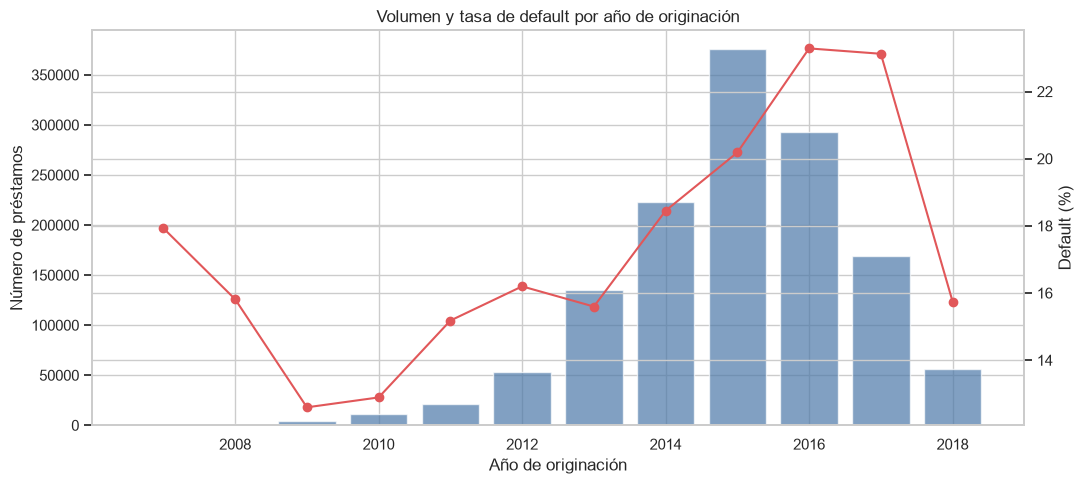

In [14]:
temporal = (
    df.dropna(subset=['issue_d'])
      .assign(anio=lambda x: x['issue_d'].dt.year)
      .groupby('anio')['default']
      .agg(n='size', tasa_default='mean')
)
temporal['tasa_default_pct'] = 100 * temporal['tasa_default']
display(temporal)
temporal.to_csv(RESULTS_DIR / 'evolucion_temporal.csv', encoding='utf-8-sig')

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(temporal.index, temporal['n'], color='#4C78A8', alpha=0.7)
ax1.set(xlabel='Año de originación', ylabel='Número de préstamos')
ax2 = ax1.twinx()
ax2.plot(temporal.index, temporal['tasa_default_pct'], color='#E15759', marker='o')
ax2.set_ylabel('Default (%)')
ax1.set_title('Volumen y tasa de default por año de originación')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

El volumen de préstamos crece con fuerza hasta 2015–2016 y luego disminuye en la parte disponible de 2018. La tasa observada llega a cerca de 23 % en 2016–2017 y baja en 2018; esa caída no debe interpretarse como una mejora definitiva, porque muchos préstamos recientes aún no han alcanzado un estado final y por ello quedaron fuera del análisis. Esta variación por cohorte respalda la recomendación de probar una partición temporal antes de usar el modelo para predecir préstamos futuros.

## 2.10 Resumen ejecutivo y decisiones preliminares

Los resultados anteriores deben interpretarse atendiendo magnitud y relevancia práctica. Con más de 1,3 millones de observaciones, valores p extremadamente pequeños son esperables incluso cuando las diferencias son modestas.

Decisiones para la siguiente etapa:

- Mantener la partición estratificada común 80/20 mediante `id` y semilla fija.
- Ajustar imputadores, codificadores y escaladores solo con entrenamiento.
- Tratar las categorías ausentes explícitamente y evaluar la agrupación de categorías con menos de 1 %.
- Mantener `annual_inc` con imputación por mediana y estandarización en la comparación principal; `log1p` queda como análisis de sensibilidad futuro.
- Conservar métricas sensibles al desbalance, en especial recall, F1, AUC ROC y AUC-PR.
- Excluir todas las variables posteriores al otorgamiento para evitar fuga de información.
- Revisar estabilidad temporal, pues la composición de préstamos y su madurez cambian entre años.